In [8]:
repo_root = Path("/Users/ecd25/microstructure-mri")
src_path = repo_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("Repository:", repo_root)
print("src:", src_path)

Repository: /Users/ecd25/microstructure-mri
src: /Users/ecd25/microstructure-mri/src


In [9]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from dmri_models import Ball, Component, Model, Sphere, Stick, Tensor, Zeppelin
from dmri_models.acquisitions import bigmac_highres, hcp
from dmri_models.acquisitions import Acquisition

In [6]:
rng = np.random.default_rng(42)
print(f"Repository root: {repo_root}")

Repository root: /Users/ecd25/microstructure-mri


In [30]:
acquisition = hcp()

# Output summary of the acquisition
acquisition.print_summary()

# Define the model with three compartments: extra-cellular space (Ball), neurites (Stick), and soma (Sphere)
# First, we create the compartments
model = Model(
    [
        Component("extra", Zeppelin(parallel_diffusivity="d_par", perpendicular_diffusivity="d_perp", orientation="axis")),
        Component("neurite", Stick(diffusivity="d_in", orientation="axis")),
        Component("csf", Ball(diffusivity="d_csf")),
        #Component("extra", Tensor()),
        #Component("soma", Sphere(radius="r_soma",diffusivity="d_sphere")),
        
    ]
)
# Then define the parameters for the model
parameters = {
    "S0": 1.0,
    "extra_fraction": 0.30,
    "neurite_fraction": 0.60,
    "csf_fraction": 0.10,
    "d_par": 2.2,   
    "d_in": 2.2,
    "d_perp": 0.6,
    "d_csf": 3.0,
    "axis": np.array([0.2, 0.7, 0.6]),
}

----------------------------------------------------------------
--------------------------------
Acquisition summary
- measurements: 288
- b-value shells (ms/um^2): 4 (tolerance: 0.100)
  - b=0.000: 18 measurements, 18 non-zero directions
  - b=0.998: 90 measurements, 90 non-zero directions
  - b=1.998: 90 measurements, 90 non-zero directions
  - b=2.996: 90 measurements, 90 non-zero directions
- gradient directions: 288 unique non-zero across 288 diffusion-weighted measurements
- b-tensor shape: 1.000
- pulse duration (ms): 10.600
- diffusion time (ms): 43.100
- gradient strength (T/m): 0.000 to 0.097
- echo time (ms): 89.500
- inversion time: n/a
- repetition time (ms): 5520.000
----------------------------------
----------------------------------------------------------------


Number of measurements: 288
Signal range: [0.001, 1.000]


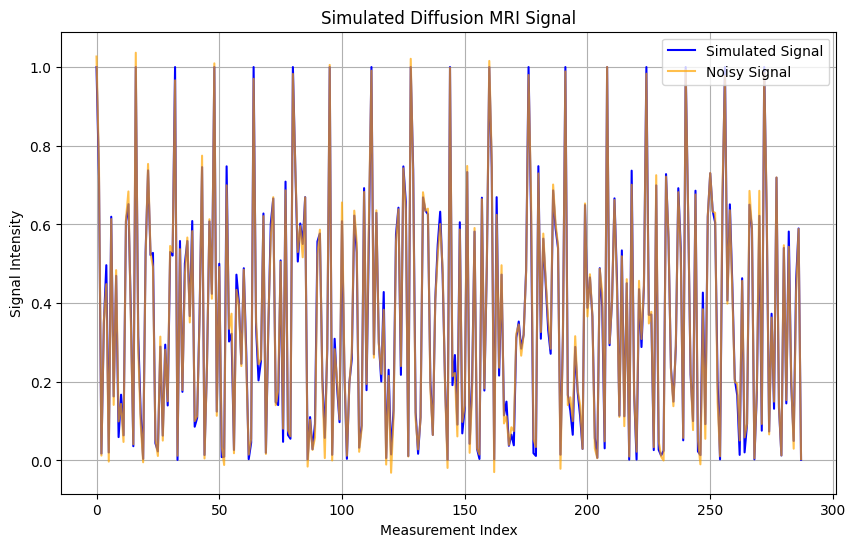

In [31]:
# Make d_perp the simulation consistent with the NODDI tortuosity model used in fitting:
# v_ic = f_neurite / (1 - f_csf), d_perp = (1 - v_ic) * d_par
v_ic_truth = parameters["neurite_fraction"] / (1.0 - parameters["csf_fraction"])
parameters["d_perp"] = (1.0 - v_ic_truth) * parameters["d_par"]

# Simulate the signal
signal = model.signal(acquisition, parameters)
# Add Gaussian noise 
SNR = 50  # Signal-to-noise ratio
noisy_signal = signal + rng.normal(0.0, parameters["S0"]/SNR, size=signal.shape)

print(f"Number of measurements: {acquisition.n_measurements}")
print(f"Signal range: [{signal.min():.3f}, {signal.max():.3f}]")


# Plot the simulated signal
plt.figure(figsize=(10, 6))
plt.plot(signal, label="Simulated Signal", color='blue')
plt.plot(noisy_signal, label="Noisy Signal", color='orange', alpha=0.7)
plt.title("Simulated Diffusion MRI Signal")
plt.xlabel("Measurement Index")
plt.ylabel("Signal Intensity")
plt.legend()
plt.grid()

Fit status: `ftol` termination condition is satisfied.
Cost (sum of squares / 2): 5.984994e-02
Estimated NODDI coordinates:
  v_iso = 0.1218 (true 0.1000)
  v_ic  = 0.6881 (true 0.6667)
Estimated fractions:
  extra   = 0.2739 (true 0.3000)
  neurite = 0.6042 (true 0.6000)
  csf     = 0.1218 (true 0.1000)
Estimated S0: 0.9961 (true 1.0000)
Estimated d_perp: 0.6863 (true 0.7333)
Estimated theta, phi: (0.8880, 1.2941)


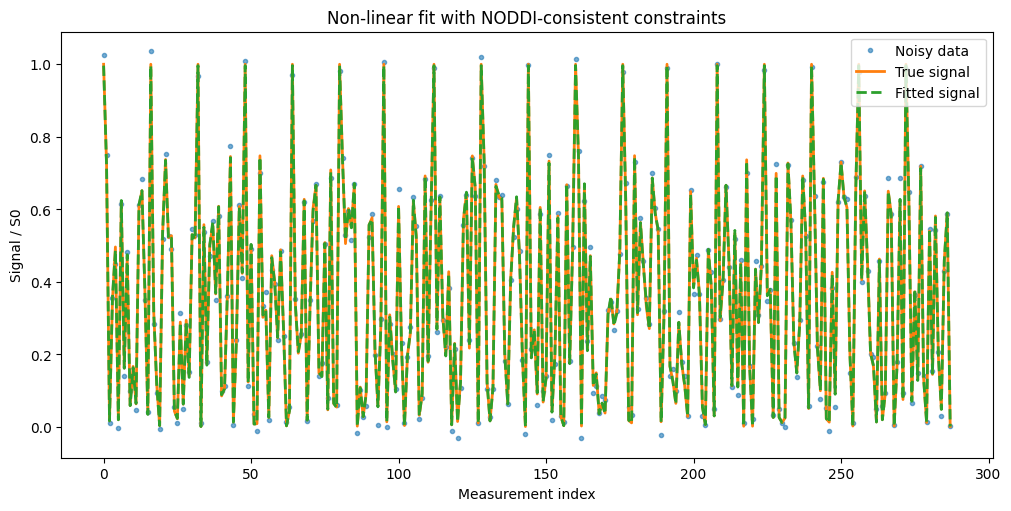

In [32]:
from scipy.optimize import least_squares

def unit_vector_from_angles(theta: float, phi: float) -> np.ndarray:
    return np.array([
        np.sin(theta) * np.cos(phi),
        np.sin(theta) * np.sin(phi),
        np.cos(theta),
    ])

def sigmoid(x: float | np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))

def noddi_fraction_map(z_iso: float, z_ic: float) -> tuple[float, float, float, float, float]:
    v_iso = float(sigmoid(z_iso))
    v_ic = float(sigmoid(z_ic))
    f_csf = v_iso
    f_neurite = (1.0 - v_iso) * v_ic
    f_extra = (1.0 - v_iso) * (1.0 - v_ic)
    return v_iso, v_ic, f_extra, f_neurite, f_csf

# Fixed diffusivities (NODDI-style assumptions)
d_in_fixed = 2.2
d_csf_fixed = 3.0
d_par_fixed = d_in_fixed

axis_true = np.asarray(parameters["axis"], dtype=float)
axis_true = axis_true / np.linalg.norm(axis_true)
theta_true = float(np.arccos(np.clip(axis_true[2], -1.0, 1.0)))
phi_true = float(np.arctan2(axis_true[1], axis_true[0]))

# Convert truth fractions to NODDI-like coordinates
f_extra_true = float(parameters["extra_fraction"])
f_neurite_true = float(parameters["neurite_fraction"])
f_csf_true = float(parameters["csf_fraction"])
v_iso_true = f_csf_true
v_ic_true = f_neurite_true / max(1e-8, 1.0 - f_csf_true)

eps = 1e-8
x0 = np.array([
    float(parameters["S0"]) * 1.02,
    np.log((v_iso_true + eps) / (1.0 - v_iso_true + eps)) + 0.05,
    np.log((v_ic_true + eps) / (1.0 - v_ic_true + eps)) - 0.05,
    theta_true + 0.03,
    phi_true - 0.03,
])

def residuals(x: np.ndarray) -> np.ndarray:
    S0_fit, z_iso, z_ic, theta, phi = x
    v_iso, v_ic, f_extra, f_neurite, f_csf = noddi_fraction_map(z_iso, z_ic)
    d_perp = (1.0 - v_ic) * d_par_fixed
    axis = unit_vector_from_angles(theta, phi)

    fit_params = {
        "S0": S0_fit,
        "extra_fraction": f_extra,
        "neurite_fraction": f_neurite,
        "csf_fraction": f_csf,
        "d_par": d_par_fixed,
        "d_perp": d_perp,
        "d_in": d_in_fixed,
        "d_csf": d_csf_fixed,
        "axis": axis,
    }
    return model.signal(acquisition, fit_params) - noisy_signal

result = least_squares(
    residuals,
    x0,
    bounds=([0.1, -8.0, -8.0, 0.0, -np.pi], [2.0, 8.0, 8.0, np.pi, np.pi]),
    method="trf",
)

S0_hat, z_iso_hat, z_ic_hat, theta_hat, phi_hat = result.x
v_iso_hat, v_ic_hat, f_extra_hat, f_neurite_hat, f_csf_hat = noddi_fraction_map(
    z_iso_hat, z_ic_hat
)
axis_hat = unit_vector_from_angles(theta_hat, phi_hat)
d_perp_hat = (1.0 - v_ic_hat) * d_par_fixed

fitted_params = {
    "S0": S0_hat,
    "extra_fraction": f_extra_hat,
    "neurite_fraction": f_neurite_hat,
    "csf_fraction": f_csf_hat,
    "d_par": d_par_fixed,
    "d_perp": d_perp_hat,
    "d_in": d_in_fixed,
    "d_csf": d_csf_fixed,
    "axis": axis_hat,
}
fitted_signal = model.signal(acquisition, fitted_params)

print("Fit status:", result.message)
print(f"Cost (sum of squares / 2): {result.cost:.6e}")
print("Estimated NODDI coordinates:")
print(f"  v_iso = {v_iso_hat:.4f} (true {v_iso_true:.4f})")
print(f"  v_ic  = {v_ic_hat:.4f} (true {v_ic_true:.4f})")
print("Estimated fractions:")
print(f"  extra   = {f_extra_hat:.4f} (true {parameters['extra_fraction']:.4f})")
print(f"  neurite = {f_neurite_hat:.4f} (true {parameters['neurite_fraction']:.4f})")
print(f"  csf     = {f_csf_hat:.4f} (true {parameters['csf_fraction']:.4f})")
print(f"Estimated S0: {S0_hat:.4f} (true {parameters['S0']:.4f})")
print(f"Estimated d_perp: {d_perp_hat:.4f} (true {parameters['d_perp']:.4f})")
print(f"Estimated theta, phi: ({theta_hat:.4f}, {phi_hat:.4f})")

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
ax.plot(noisy_signal, '.', alpha=0.6, label='Noisy data')
ax.plot(signal, '-', linewidth=2, label='True signal')
ax.plot(fitted_signal, '--', linewidth=2, label='Fitted signal')
ax.set_title('Non-linear fit with NODDI-consistent constraints')
ax.set_xlabel('Measurement index')
ax.set_ylabel('Signal / S0')
ax.legend()
plt.show()

---

# Two compartment: Tensor and Dot

In [ ]:
# Adapting Amy's notebook

two_model = Model(
    [
        Component("extra", Zeppelin(eigenvalues=("d1", "d2", "d3"), eigenvectors="axis",), fraction="extra_fraction",),
        Component("soma", Ball(radius="r_soma", diffusivity="d_sphere"), fraction="soma_fraction",),
    ]
)

# Then define the parameters for the model
two_parameters = {
    "S0": 1.0,
    "extra_fraction": 0.80,
    "soma_fraction": 0.20,
    "r_soma": 0.001,
    "d_sphere": 0.0,
    "d1": 1.7,
    "d2": 0.5,
    "d3": 0.5,
    "axis": np.eye(3),
}

#idk what the axis should be lol i'm making this up

In [ ]:
dot_zep_model = Model(
    [
        Component("extra", Zeppelin(eigenvalues=("d1", "d2", "d3"), eigenvectors="axis",), fraction="extra_fraction",),
        Component("soma", Ball(radius="r_soma", diffusivity="d_sphere"), fraction="soma_fraction",),
    ]
)

Number of measurements: 288
Signal range: [0.001, 1.000]


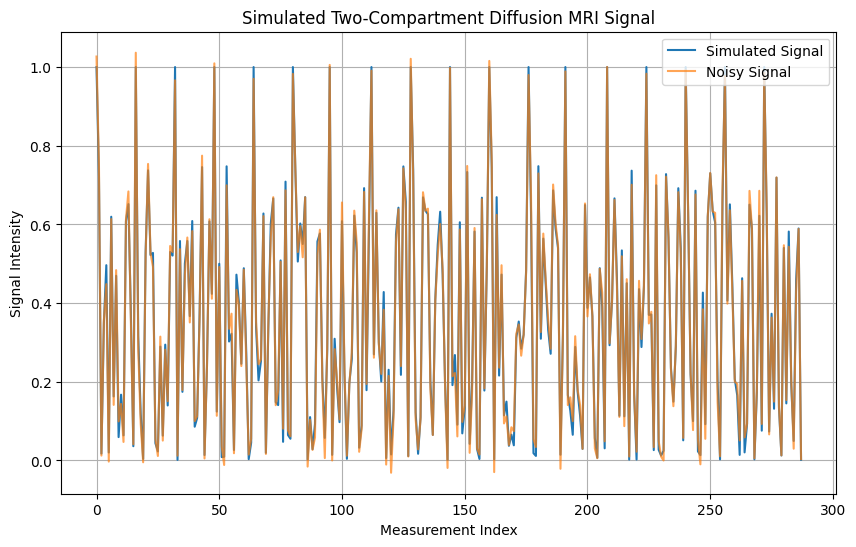

In [42]:
two_signal = two_model.signal(acquisition, two_parameters)
# Add Gaussian noise 

two_noisy_signal = two_signal + rng.normal(0.0, parameters["S0"]/SNR, size=two_signal.shape)

print(f"Number of measurements: {acquisition.n_measurements}")
print(f"Signal range: [{signal.min():.3f}, {signal.max():.3f}]")

# Plot the simulated signal
plt.figure(figsize=(10, 6))
plt.plot(signal, label="Simulated Signal")
plt.plot(noisy_signal, label="Noisy Signal", alpha=0.7)
plt.title("Simulated Two-Compartment Diffusion MRI Signal")
plt.xlabel("Measurement Index")
plt.ylabel("Signal Intensity")
plt.legend()
plt.grid()

In [47]:
two_fitted_params = {
    "S0": S0_hat,
    "extra_fraction": f_extra_hat,
    "soma_fraction": f_soma_hat,

    "r_soma": r_soma_hat,
    "d_sphere": d_sphere_hat,
    "d1": d1_hat,
    "d2": d2_hat,
    "d3": d3_hat,
    "axis": np.eye(3),
}

two_fitted_signal = two_model.signal(acquisition, two_fitted_params)

In [51]:
print("Fit status:", result.message)
print(f"Cost (sum of squares / 2): {result.cost:.6e}")

print("Estimated fractions:")
print(f"  extra   = {f_extra_hat:.4f} (true {two_parameters['extra_fraction']:.4f})")
print(f"  soma = {f_soma_hat:.4f} (true {two_parameters['soma_fraction']:.4f})")
print("Estimated tensor:")
print(f"Estimated S0: {S0_hat:.4f} (true {two_parameters['S0']:.4f})")
print(f"Estimated d1: {d1_hat:.4f} (true {two_parameters['d1']:.4f})")
print(f"Estimated d2: {d2_hat:.4f} (true {two_parameters['d2']:.4f})")
print(f"Estimated d3: {d3_hat:.4f} (true {two_parameters['d3']:.4f})")

print("Estimated soma:")
print(f"  r_soma = {r_soma_hat:.4f} (true {r_soma_true:.4f})")
print(f"  d_sphere  = {d_sphere_hat:.4f} (true {d_sphere_true:.4f})")

Fit status: `ftol` termination condition is satisfied.
Cost (sum of squares / 2): 5.180213e-02
Estimated fractions:
  extra   = 0.8037 (true 0.8000)
  soma = 0.1963 (true 0.2000)
Estimated tensor:
Estimated S0: 1.0003 (true 1.0000)
Estimated d1: 1.6859 (true 1.7000)
Estimated d2: 0.4854 (true 0.5000)
Estimated d3: 0.4986 (true 0.5000)
Estimated soma:
  r_soma = 0.1223 (true 0.0010)
  d_sphere  = 0.0343 (true 1.0000)


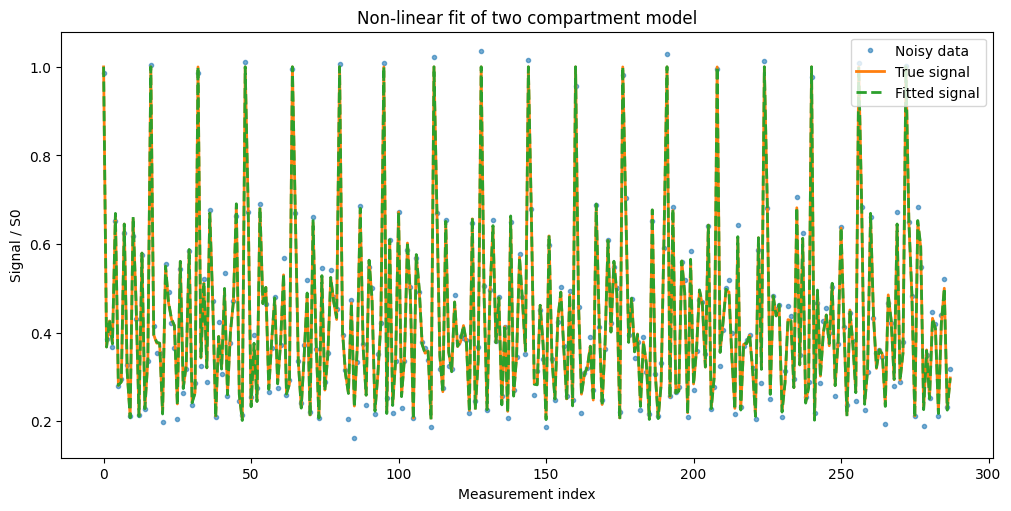

In [52]:
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
ax.plot(two_noisy_signal, '.', alpha=0.6, label='Noisy data')
ax.plot(two_signal, '-', linewidth=2, label='True signal')
ax.plot(two_fitted_signal, '--', linewidth=2, label='Fitted signal')

#should that be two_fitted

ax.set_title('Non-linear fit of two compartment model')
ax.set_xlabel('Measurement index')
ax.set_ylabel('Signal / S0')
ax.legend()
plt.show()

In [12]:
def _fibonacci_directions(n: int) -> np.ndarray:
    """Deterministic approximately uniform unit directions on the sphere."""
    if n < 1:
        raise ValueError("n must be at least one.")
    indices = np.arange(n, dtype=float)
    z = 1.0 - 2.0 * (indices + 0.5) / n
    theta = np.pi * (1.0 + 5.0**0.5) * indices
    radius = np.sqrt(np.maximum(0.0, 1.0 - z**2))
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)
    return np.column_stack((x, y, z))


def _paths(name: str):
    directory = files("dmri_models").joinpath("data", "acquisitions", name)
    return directory.joinpath("bvals"), directory.joinpath("bvecs")


def _pgse_preset(
    name: str,
    *,
    pulse_duration: float,
    diffusion_time: float,
    echo_time: float | None = None,
    repetition_time: float | None = None,
) -> Acquisition:
    bvals, bvecs = _paths(name)
    return Acquisition.from_fsl(
        bvals,
        bvecs,
        bval_unit="s/mm^2",
        b0_threshold=0.05,
        rectangular_pgse=True,
        pulse_duration=pulse_duration,
        diffusion_time=diffusion_time,
        b_tensor_shape=1.0,
        echo_time=echo_time,
        repetition_time=repetition_time,
    )


In [33]:
def open_neurosurg() -> Acquisition:
    """Open neurosurgical dataset.

    Shell layout: b = 0, 400, 800, 16000, 3200 s/mm²
    (0.0, 0.4, 0.8, 1.6, 3.2 ms/µm²), 4, 8, 8, 16 directions per non-zero shell,
    and 4 b=0 measurements. PGSE timing: 
    Δ={35.9, 40.9, 45.9, 50.9, 55.9, 60.9, 65.9}ms, 
    δ={19.9, 24.9, 29.9, 34.9, 39.9, 44.9, 49.9}ms, 
    echo times: TE={75, 85, 95, 105, 115, 125, 135}
    """
    non_zero_shells = np.array([400, 800, 1600, 3200], dtype=float)
    directions_per_shell = np.array([4, 8, 8, 16], dtype=int)
    b0_count = 4

    directions_per_shell = np.array([4, 8, 8, 16], dtype=int)
    gradients = [np.zeros((b0_count, 3), dtype=float)]
    bvals = [np.zeros(b0_count, dtype=float)]

    for shell, n_directions in zip(non_zero_shells, directions_per_shell):
        gradients.append(_fibonacci_directions(n_directions))
        bvals.append(np.full(n_directions, shell, dtype=float))

    return Acquisition.from_pgse(
        np.concatenate(bvals),
        b_unit="s/mm^2",
        pulse_duration=24.9,
        diffusion_time=40.9,
        gradients=np.vstack(gradients),
        normalize_gradients=False,
        b_tensor_shape=1.0,
    )

In [35]:
acquisition_2 = open_neurosurg()

# Output summary of the acquisition
acquisition_2.print_summary()

----------------------------------------------------------------
--------------------------------
Acquisition summary
- measurements: 40
- b-value shells (ms/um^2): 5 (tolerance: 0.100)
  - b=0.000: 4 measurements, 0 non-zero directions
  - b=0.400: 4 measurements, 4 non-zero directions
  - b=0.800: 8 measurements, 8 non-zero directions
  - b=1.600: 8 measurements, 8 non-zero directions
  - b=3.200: 16 measurements, 16 non-zero directions
- gradient directions: 28 unique non-zero across 36 diffusion-weighted measurements
- b-tensor shape: 1.000
- pulse duration (ms): 24.900
- diffusion time (ms): 40.900
- gradient strength (T/m): 0.000 to 0.047
- echo time: n/a
- inversion time: n/a
- repetition time: n/a
----------------------------------
----------------------------------------------------------------


In [32]:
print(acquisition_2)

Acquisition(b_values=array([0. , 0. , 0. , 0. , 0.4, 0.4, 0.4, 0.4, 0.8, 0.8, 0.8, 0.8, 0.8,
       0.8, 0.8, 0.8, 1.6, 1.6, 1.6, 1.6, 1.6, 1.6, 1.6, 1.6, 3.2, 3.2,
       3.2, 3.2, 3.2, 3.2, 3.2, 3.2, 3.2, 3.2, 3.2, 3.2, 3.2, 3.2, 3.2,
       3.2]), gradients=array([[ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.66143783,  0.        ,  0.75      ],
       [-0.71395435, -0.65404067,  0.25      ],
       [ 0.08464959,  0.96453846, -0.25      ],
       [ 0.40244448, -0.52491756, -0.75      ],
       [ 0.48412292,  0.        ,  0.875     ],
       [-0.5756084 , -0.52730444,  0.625     ],
       [ 0.08104582,  0.92347527,  0.375     ],
       [ 0.60366672, -0.78737634,  0.125     ],
       [-0.97699012,  0.1728158 , -0.125     ],
       [ 0.78218209,  0.49756022, -0.375     ],
       [-0.20265355, -0.75386109, -0.625     ],
       [-0.22313565